<a href="https://colab.research.google.com/github/KuldeepIsharwal/Machine-Learning-Basics/blob/main/Softmax_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('/content/Iris.csv')

In [8]:
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
131,132,7.9,3.8,6.4,2.0,Iris-virginica
1,2,4.9,3.0,1.4,0.2,Iris-setosa
72,73,6.3,2.5,4.9,1.5,Iris-versicolor
44,45,5.1,3.8,1.9,0.4,Iris-setosa
89,90,5.5,2.5,4.0,1.3,Iris-versicolor


In [13]:
df['Species'].describe()

,Species
count,150
unique,3
top,Iris-setosa
freq,50


/tmp/ipykernel_1078/3059423068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='viridis')


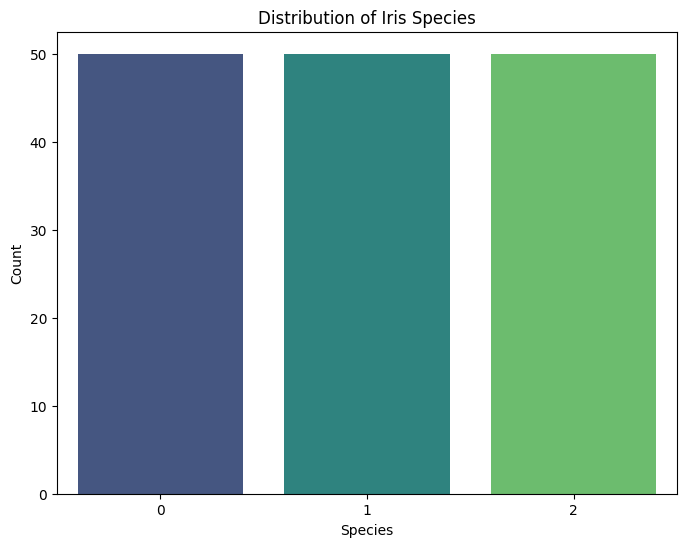

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Species', data=df, palette='viridis')
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

In [15]:
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])

In [16]:
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
15,16,5.7,4.4,1.5,0.4,0
36,37,5.5,3.5,1.3,0.2,0
141,142,6.9,3.1,5.1,2.3,2
78,79,6.0,2.9,4.5,1.5,1
23,24,5.1,3.3,1.7,0.5,0


In [20]:

df = df[['SepalLengthCm','PetalLengthCm','Species']]

In [28]:
X = df[['SepalLengthCm', 'PetalLengthCm']]
y = df['Species']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
clf = LogisticRegression(multi_class='multinomial')
clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [24]:
y_pred = clf.predict(X_test)

In [25]:
accuracy_score(y_test, y_pred)

1.0

In [26]:
pd.DataFrame(confusion_matrix(y_test, y_pred), columns=encoder.classes_, index=encoder.classes_)

,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,19,0,0
Iris-versicolor,0,13,0
Iris-virginica,0,0,13


In [31]:
#prediction
query = np.array([2, 5]).reshape(1, -1)
clf.predict_proba(query)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.00164475, 0.04522225, 0.953133  ]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


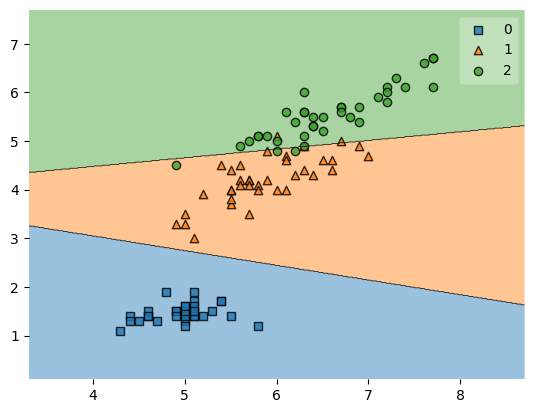

In [33]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train.values, y_train.values, clf)

plt.show()